# Introduction to Fourier Transformation

This notebook introduces the core ideas behind the **Discrete Fourier Transform (DFT)** that power the analysis in `Fourier_Analysis_Demo.ipynb`.

If you already know what frequency, amplitude, and phase mean in the context of a Fourier transform, feel free to skip ahead to `Fourier_Analysis_Demo.ipynb`. Otherwise, this notebook builds the concepts from scratch using simple toy signals, then applies them to the real phototaxis stimulus signal used in the manuscript.

## Table of Contents
- Step 0: Setup
- Step 1: What is a periodic signal?
- Step 2: From time domain to frequency domain — the Discrete Fourier Transform
- Step 3: Reading the DFT output — amplitude and phase spectra
- Step 4: Extracting frequency, amplitude, and phase of the dominant component
- Step 5: Reconstructing a signal from its dominant frequency component
- Step 6: Robustness to noise
- Step 7: Applying this to the phototaxis stimulus signal
- Wrap-up

# Step 0: Setup

We only need `numpy`, `scipy`, `pandas`, and `matplotlib` for this notebook — no calcium imaging data needs to be downloaded.

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

# Get the project root (assume the notebook lives inside /notebooks)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)

Project root: D:\Github\Fourier
Data folder: D:\Github\Fourier\data


# Step 1: What is a periodic signal?

A **periodic signal** repeats itself after a fixed interval of time, called the **period** or **wavelength** ($\lambda$). Its **frequency** ($F$) is simply the inverse of the wavelength: $F = 1/\lambda$.

A pure periodic signal can be described by a cosine wave with three parameters:
- **Amplitude ($A$)** — how large the oscillation is (the height of the wave).
- **Frequency ($F$)** — how many cycles occur per unit time.
- **Phase ($P$)** — the time offset of the wave's peak, i.e. *when* within a cycle the peak occurs.

$$x(t) = A \cdot \cos\big(2\pi F (t - P)\big)$$

Let's construct one and look at it.

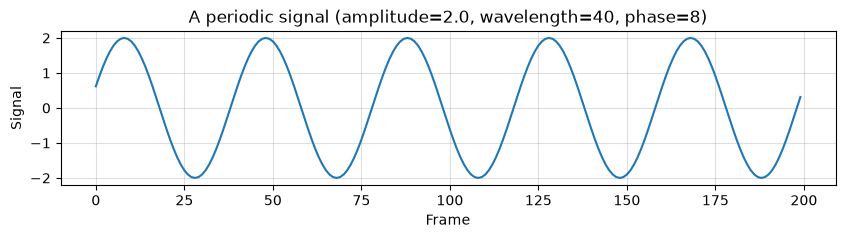

In [2]:
# Ground-truth parameters for our toy signal
true_amplitude = 2.0
true_wavelength = 40      # frames per cycle
true_frequency = 1 / true_wavelength
true_phase = 8            # frames — the peak occurs at t = 8, 48, 88, ...

num_frames = 200
t = np.arange(num_frames)

signal_clean = true_amplitude * np.cos(2 * np.pi * true_frequency * (t - true_phase))

plt.figure(figsize=(10, 2))
plt.plot(t, signal_clean)
plt.title(f"A periodic signal (amplitude={true_amplitude}, wavelength={true_wavelength}, phase={true_phase})")
plt.xlabel("Frame")
plt.ylabel("Signal")
plt.grid(alpha=0.4)
plt.show()

Real signals — like calcium imaging traces — are rarely a single clean cosine wave. They are more often a **mixture of several periodic components plus noise**. The question the Fourier Transform answers is:

> Given a signal, which frequencies does it contain, and how strong (amplitude) and how shifted in time (phase) is each one?

# Step 2: From time domain to frequency domain — the Discrete Fourier Transform

The **Discrete Fourier Transform (DFT)** decomposes a signal of $t$ frames into a sum of $t$ complex sinusoids, one for each frequency $F_k = k/t$ (for $k = 1, ..., t$). For a signal $x_n$, the DFT is defined as:

$$Y_k = \sum_{n=1}^{t} x_n \cdot e^{-2\pi i \frac{kn}{t}}, \qquad 1 \le k \le t$$

This is exactly the formula used in the manuscript's Methodology section. It looks intimidating, but it is simply asking: *"how much does a sinusoid of frequency $k/t$ correlate with my signal?"* — for every possible frequency $k/t$.

To demystify it, let's implement it directly from the formula (a **naive DFT**), and compare the result against SciPy's fast, optimized implementation (`scipy.fft.fft`), which computes the exact same quantity.

In [3]:
def naive_dft(x):
    # Direct implementation of the DFT formula. O(t^2) -- fine for small signals, never used in the
    # real analysis pipeline (we always use scipy.fft, which uses the much faster FFT algorithm).
    t = len(x)
    Y = np.zeros(t, dtype=complex)
    for k in range(t):
        total = 0j
        for n in range(t):
            total += x[n] * np.exp(-2j * np.pi * k * n / t)
        Y[k] = total
    return Y

# Compare our from-scratch implementation against scipy.fft on a short signal
short_signal = signal_clean[:60]

Y_naive = naive_dft(short_signal)
Y_scipy = scipy.fft.fft(short_signal)

print("Max difference between naive DFT and scipy.fft.fft:", np.max(np.abs(Y_naive - Y_scipy)))

Max difference between naive DFT and scipy.fft.fft: 4.818030243521319e-13


The difference is essentially zero (up to floating-point rounding) — `scipy.fft.fft` computes exactly the same DFT, just much faster (using the Fast Fourier Transform algorithm). From now on we will always use `scipy.fft`.

Since our neural activity traces are **real-valued** (not complex), the DFT output is symmetric: the component at frequency $k/t$ is the complex conjugate of the component at $(t-k)/t$. `scipy.fft.rfft` exploits this and only returns the non-redundant half of the spectrum, i.e. $k \in [1, m]$ where $m = t/2$ for even $t$ (matching the manuscript's convention). This is what we use throughout the analysis.

# Step 3: Reading the DFT output — amplitude and phase spectra

Each DFT coefficient $Y_k$ is a **complex number**. Its two components carry the two pieces of information we care about:

- **Amplitude spectrum**: $A_k = |Y_k| \cdot \dfrac{2}{t}$ — the strength of the periodic component at frequency $F_k = k/t$.
- **Phase spectrum**: $\theta_k = \arg(Y_k)$ — the phase (in radians) of that component.

Let's compute both for our toy signal and visualize the amplitude spectrum — this is directly analogous to Figure 1B in the manuscript.

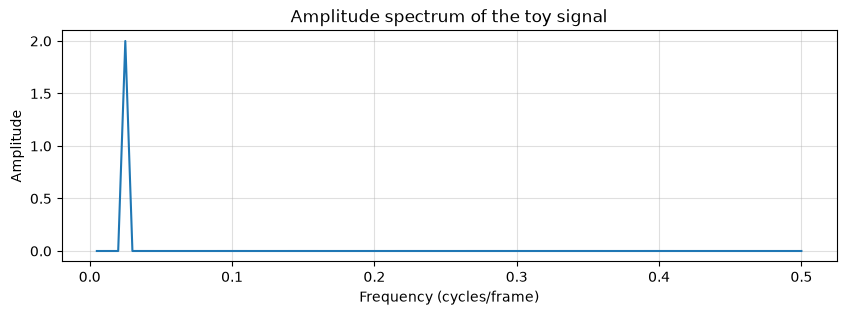

In [4]:
raw_result = scipy.fft.rfft(signal_clean)

# scipy.fft.rfft returns bins k = 0, 1, ..., m, where bin 0 is the DC (zero-frequency) component.
# The manuscript's convention only keeps 1 <= k <= m, so we drop the DC bin before labeling frequencies.
result = raw_result[1:]

t_len = len(signal_clean)
freq_basis = np.arange(1, len(result) + 1) / t_len       # F_k = k / t, for k = 1, ..., m
amplitude_spectrum = np.abs(result) * (2 / t_len)          # A_k
phase_spectrum = np.angle(result)                           # theta_k (radians)

plt.figure(figsize=(10, 3))
plt.plot(freq_basis, amplitude_spectrum)
plt.xlabel("Frequency (cycles/frame)")
plt.ylabel("Amplitude")
plt.title("Amplitude spectrum of the toy signal")
plt.grid(alpha=0.4)
plt.show()

There is a single sharp peak at $F = 1/40 = 0.025$ — exactly the frequency we used to generate the signal. This is the essence of Fourier analysis: **a periodic component in the time domain shows up as a peak in the frequency domain.**

# Step 4: Extracting frequency, amplitude, and phase of the dominant component

To identify the properties of the dominant periodic component, we:
1. Find the frequency bin $k$ with the highest amplitude.
2. Read off $F_k$ (frequency), $A_k$ (amplitude) directly.
3. Convert the phase $\theta_k$ (in radians) into a more intuitive unit — **frames** — using the manuscript's conversion:

$$P_k = \lambda_k \cdot \frac{(-\theta_k) \bmod 2\pi}{2\pi}, \qquad \lambda_k = \frac{1}{F_k}$$

$P_k$ tells us *at which frame* (within one cycle) the signal reaches its peak — directly comparable to `true_phase` used to generate the signal above.

In [5]:
peak_idx = np.argmax(amplitude_spectrum)

est_frequency = freq_basis[peak_idx]
est_wavelength = 1 / est_frequency
est_amplitude = amplitude_spectrum[peak_idx]
est_phase = est_wavelength * ((-phase_spectrum[peak_idx]) % (2 * np.pi)) / (2 * np.pi)

print(f"Estimated frequency:  {est_frequency:.5f}  (true: {true_frequency:.5f})")
print(f"Estimated wavelength: {est_wavelength:.2f}  (true: {true_wavelength})")
print(f"Estimated amplitude:  {est_amplitude:.3f}  (true: {true_amplitude})")
print(f"Estimated phase:      {est_phase:.2f}  (true: {true_phase})")

Estimated frequency:  0.02500  (true: 0.02500)
Estimated wavelength: 40.00  (true: 40)
Estimated amplitude:  2.000  (true: 2.0)
Estimated phase:      8.00  (true: 8)


The recovered frequency, amplitude, and phase all match the ground-truth values we used to build the signal. This is exactly the calculation performed by `check_frequency`, `check_amplitude`, and `check_phase` in `demo_functions.py`, which are used throughout `Fourier_Analysis_Demo.ipynb` on real neuron traces instead of this toy signal.

# Step 5: Reconstructing a signal from its dominant frequency component

Once we know a component's frequency, amplitude, and phase, we can reconstruct a sinusoidal approximation of the signal using the manuscript's formula:

$$S(F_k, A_k, P_k) = A_k \cdot \cos\big(2\pi F_k (x - P_k)\big)$$

This is the same sinusoidal approximation shown in Figure 1B, and is what we overlay on real neuron traces in the main analysis notebook.

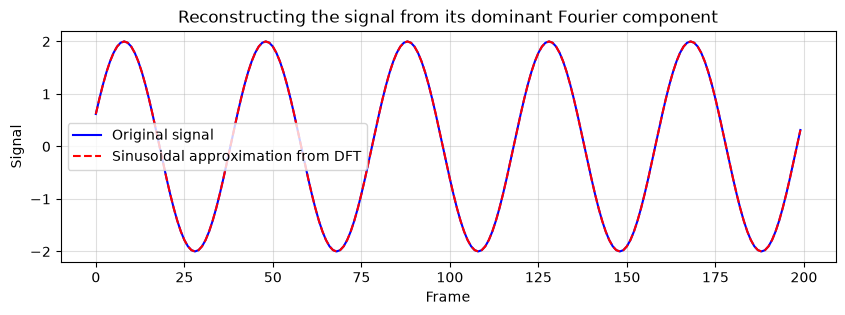

In [6]:
x = np.arange(num_frames)
reconstructed = est_amplitude * np.cos(2 * np.pi * est_frequency * (x - est_phase))

plt.figure(figsize=(10, 3))
plt.plot(x, signal_clean, label="Original signal", color="blue")
plt.plot(x, reconstructed, label="Sinusoidal approximation from DFT", color="red", linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Signal")
plt.legend()
plt.grid(alpha=0.4)
plt.title("Reconstructing the signal from its dominant Fourier component")
plt.show()

# Step 6: Robustness to noise

Real calcium imaging traces are noisy. Does the DFT still recover the correct frequency, amplitude, and phase when we corrupt the signal with random noise? Let's find out.

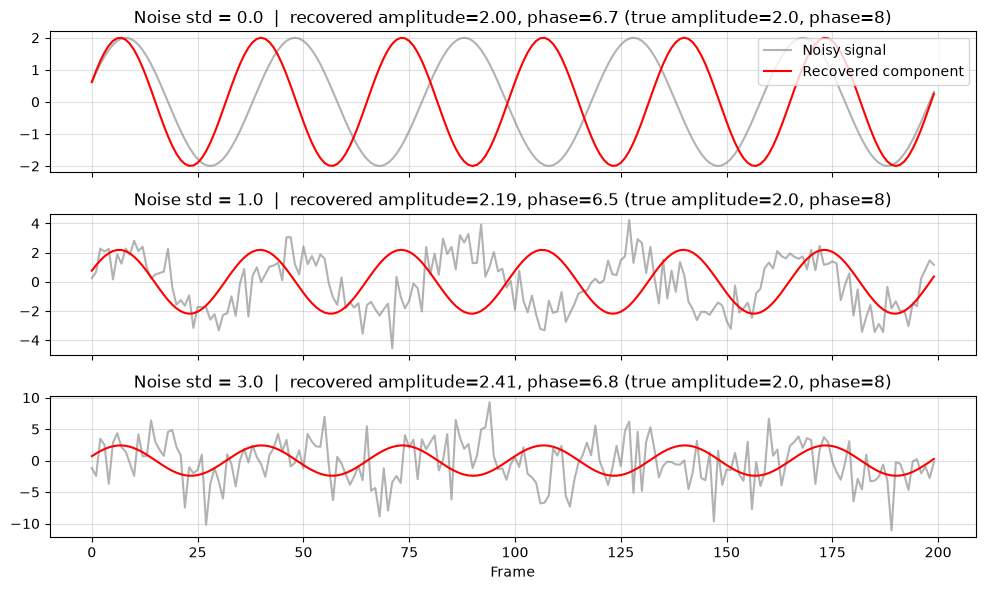

In [7]:
np.random.seed(0)
noise_levels = [0.0, 1.0, 3.0]

fig, axes = plt.subplots(len(noise_levels), 1, figsize=(10, 6), sharex=True)

for ax, noise_std in zip(axes, noise_levels):
    noisy_signal = signal_clean + np.random.normal(0, noise_std, size=num_frames)

    result = scipy.fft.rfft(noisy_signal)
    amp_spec = np.abs(result) * (2 / len(noisy_signal))
    phase_spec = np.angle(result)

    peak_idx = np.argmax(amp_spec)
    freq_k = freq_basis[peak_idx]
    amp_k = amp_spec[peak_idx]
    phase_k = (1 / freq_k) * ((-phase_spec[peak_idx]) % (2 * np.pi)) / (2 * np.pi)

    ax.plot(t, noisy_signal, color="grey", alpha=0.6, label="Noisy signal")
    ax.plot(t, amp_k * np.cos(2 * np.pi * freq_k * (t - phase_k)), color="red", label="Recovered component")
    ax.set_title(f"Noise std = {noise_std}  |  recovered amplitude={amp_k:.2f}, phase={phase_k:.1f} "
                 f"(true amplitude={true_amplitude}, phase={true_phase})")
    ax.grid(alpha=0.4)

axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Frame")
plt.tight_layout()
plt.show()

Even as the noise grows large enough to make the periodic pattern hard to see by eye, the DFT still recovers a component close to the true amplitude and phase — as long as the periodic signal is present across enough cycles. This is exactly why the Fourier approach works on single-neuron calcium traces, which are individually noisy but repeat over many stimulus trials.

# Step 7: Applying this to the phototaxis stimulus signal

Finally, let's apply everything we've learned to a **real signal** from the manuscript: the phototaxis stimulus itself. This is a small file (`data/stimulus.xlsx`) so no large download is required — this is the same file used at the start of `Fourier_Analysis_Demo.ipynb`.

Each element of the stimulus array encodes, per imaging frame, whether the left or right hemifield was dark:
- `1` → right-side phototactic stimulus
- `2` → left-side phototactic stimulus
- `0` → baseline (no stimulus)

We isolate the left-side stimulus as a boxcar (0/1) signal and run it through the same DFT pipeline as above.

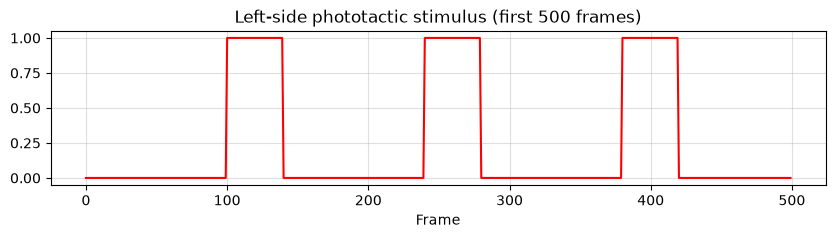

In [8]:
stimulus = pd.read_excel(DATA_DIR / "stimulus.xlsx", header=None).to_numpy()[0]
stimulus_left = np.array([1 if x == 2 else 0 for x in stimulus], dtype=float)

plt.figure(figsize=(10, 2))
plt.plot(stimulus_left[:500], color="red")
plt.xlabel("Frame")
plt.title("Left-side phototactic stimulus (first 500 frames)")
plt.grid(alpha=0.4)
plt.show()

In [9]:
# Transform the signal to the complex plane
stimulus_left_fft_result = scipy.fft.rfft(stimulus_left)

# Take the magnitude of each complex result -> unnormalized amplitude spectrum
stimulus_left_fft_absResult = np.abs(stimulus_left_fft_result)

# Identify peaks; each peak corresponds to a strong periodic component
stimulus_left_peak_indices = scipy.signal.find_peaks(stimulus_left_fft_absResult)[0]

# Find the peak corresponding to the strongest periodic signal
stimulus_left_majorPeakIdx = stimulus_left_peak_indices[np.argmax(stimulus_left_fft_absResult[stimulus_left_peak_indices])]

# The index divided by the signal length gives the frequency
stimulus_left_frequency = stimulus_left_majorPeakIdx / len(stimulus_left)

# The wavelength (length of each cycle, in frames) is the inverse of frequency
stimulus_left_wavelength = 1 / stimulus_left_frequency

# The amplitude of this component, properly normalized
stimulus_left_amplitude = stimulus_left_fft_absResult[stimulus_left_majorPeakIdx] * (2 / len(stimulus_left))

# The phase of this component, converted from radians to frames
stimulus_left_phase = (stimulus_left_wavelength
                        * ((-np.angle(stimulus_left_fft_result[stimulus_left_majorPeakIdx])) % (2 * math.pi))
                        / (2 * math.pi))

print(f"The stimulus-left frequency is {stimulus_left_frequency:.6f}")
print(f"The stimulus-left wavelength is {stimulus_left_wavelength:.1f} frames")
print(f"The stimulus-left amplitude is {stimulus_left_amplitude:.3f}")
print(f"The stimulus-left phase is {stimulus_left_phase:.2f} frames")

The stimulus-left frequency is 0.007143
The stimulus-left wavelength is 140.0 frames
The stimulus-left amplitude is 0.498
The stimulus-left phase is 119.50 frames


This matches the stimulus design described in the manuscript: a **140-frame** cycle (wavelength), within which the left-side stimulus block is presented for 40 frames starting at frame 100 (so the boxcar's phase, i.e. its Fourier-approximated peak, falls near the middle of that block). We will reuse this exact frequency (`1/140`) as the **stimulus frequency** throughout `Fourier_Analysis_Demo.ipynb` to identify stimulus-locked neurons.

# Wrap-up

We've covered the three quantities that the Fourier-based pipeline extracts from every signal:

| Quantity | Meaning | Manuscript symbol |
|---|---|---|
| Frequency | How many cycles per frame | $F_k = k/t$ |
| Amplitude | Strength of the periodic component | $A_k = \lvert Y_k \rvert \cdot 2/t$ |
| Phase | Timing of the peak response, in frames | $P_k$ |

These three parameters are exactly what `demo_functions.py` computes for every neuron in `Fourier_Analysis_Demo.ipynb`, where amplitude and phase become the two selection criteria used to identify stimulus-locked neurons (Figure 3 in the manuscript).

**Next:** continue to `Fourier_Analysis_Demo.ipynb` to apply this pipeline to real zebrafish calcium imaging data.